# Лабораторная работа №3. Вариант 2

**Тема:** методы многомерного поиска.

**Параметры варианта 9:** $a = 150,\ b = 2,\ f_0 = 100,\ n = 3$.

**Тестовая функция (Розенброка):**
$$f(x) = \sum_{i=1}^{n-1}\bigl[a(x_i^2 - x_{i+1})^2 + b(x_i - 1)^2\bigr] + f_0$$

Для $n=3$:
$$f(x) = 150(x_1^2 - x_2)^2 + 2(x_1 - 1)^2 + 10$$

**Реализуем методы:**
1. Флетчера-Ривза (FR) — сопряжённые градиенты
2. Полака-Рибьера (PR) — сопряжённые градиенты
3. DFP — квазиньютоновский (Девидон-Флетчер-Пауэлл)
4. BFGS — квазиньютоновский (Бройден-Флетчер-Гольдфарб-Шенно)
5. L-BFGS — квазиньютоновский с ограниченной памятью

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import time

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## Определение функции и градиента

Задаём параметры варианта 2, реализуем функцию `rosen(x)` и её градиент `rosen_grad(x)`.

In [18]:
A, B, F0, N = 150, 2, 100, 3

def rosen(x):
    """Функция Розенброка для n = 3 с защитой от переполнения"""
    x = np.asarray(x, dtype=float)
    s = 0.0
    for i in range(N - 1):
        term1 = A * (x[i]**2 - x[i+1])**2
        term2 = B * (x[i] - 1)**2
        # Защита от переполнения
        if term1 > 1e100 or term2 > 1e100:
            return 1e100
        s += term1 + term2
    return s + F0

def rosen_grad(x):
    """Градиент функции Розенброка для n = 3"""
    x = np.asarray(x, dtype=float)
    g = np.zeros(N)
    for i in range(N - 1):
        diff = x[i]**2 - x[i+1]
        # Защита от переполнения
        if abs(diff) > 1e50:
            return np.sign(diff) * 1e50 * np.ones(N)
        g[i]   += 4 * A * diff * x[i] + 2 * B * (x[i] - 1)
        g[i+1] += -2 * A * diff
    return g

# Проверка
print(f'f(1,1,1) = {rosen([1.0, 1.0, 1.0])}  (ожидаем {F0})')
print(f'grad(1,1,1) = {rosen_grad([1.0, 1.0, 1.0])}  (ожидаем [0, 0, 0])')

f(1,1,1) = 100.0  (ожидаем 100)
grad(1,1,1) = [0. 0. 0.]  (ожидаем [0, 0, 0])


## Аналитический поиск стационарных точек

Проверим достаточное условие через гессиан.

In [32]:
def rosen_hess(x):
    """Гессиан функции Розенброка для n = 3"""
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    
    # Первая переменная (i=0)
    H[0, 0] = 12 * A * x[0]**2 - 4 * A * x[1] + 2 * B
    H[0, 1] = -4 * A * x[0]
    H[1, 0] = -4 * A * x[0]
    
    # Вторая переменная (i=1)
    H[1, 1] = 12 * A * x[1]**2 - 4 * A * x[2] + 2 * B + 2 * A
    H[1, 2] = -4 * A * x[1]
    H[2, 1] = -4 * A * x[1]
    
    # Третья переменная (i=2) — последняя, только квадратичный член
    H[2, 2] = 2 * A
    
    return H

# Проверка в точке минимума (1, 1, 1)
x_star = np.array([1.0, 1.0, 1.0])
H_star = rosen_hess(x_star)

print('='*60)
print(f'Гессиан в точке минимума (1, 1, 1) для n=3, a={A}, b={B}:')
print('='*60)
print(H_star)

print(f'\nОпределитель: {np.linalg.det(H_star):.2f}')
print(f'Собственные значения: {np.linalg.eigvalsh(H_star)}')

# Проверка положительной определённости
if np.all(np.linalg.eigvalsh(H_star) > 0):
    print('\n→ (1, 1, 1) — точка локального (и глобального) минимума ✓')
else:
    print('\n→ Гессиан не положительно определён! Проверьте формулу.')

Гессиан в точке минимума (1, 1, 1) для n=3, a=150, b=2:
[[1204. -600.    0.]
 [-600. 1504. -600.]
 [   0. -600.  300.]]

Определитель: 1804800.00
Собственные значения: [9.49714711e-01 9.03335427e+02 2.10371486e+03]

→ (1, 1, 1) — точка локального (и глобального) минимума ✓


## Визуализация функции

Функция Розенброка имеет «банановую долину» — узкий изогнутый овраг, по которому методы должны пробираться к минимуму.

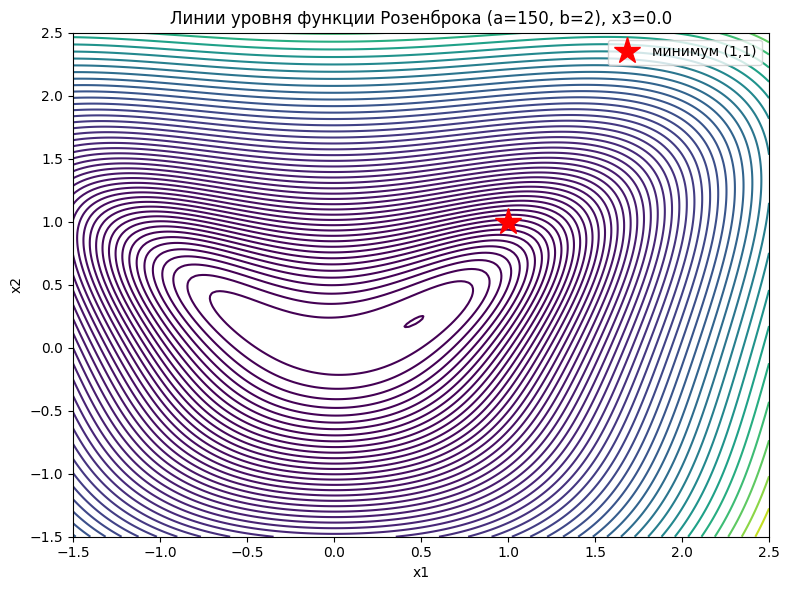

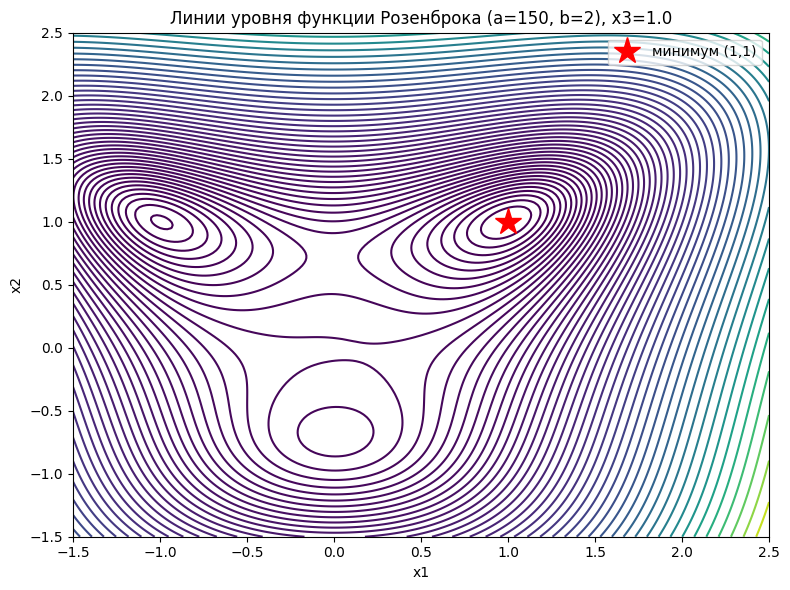

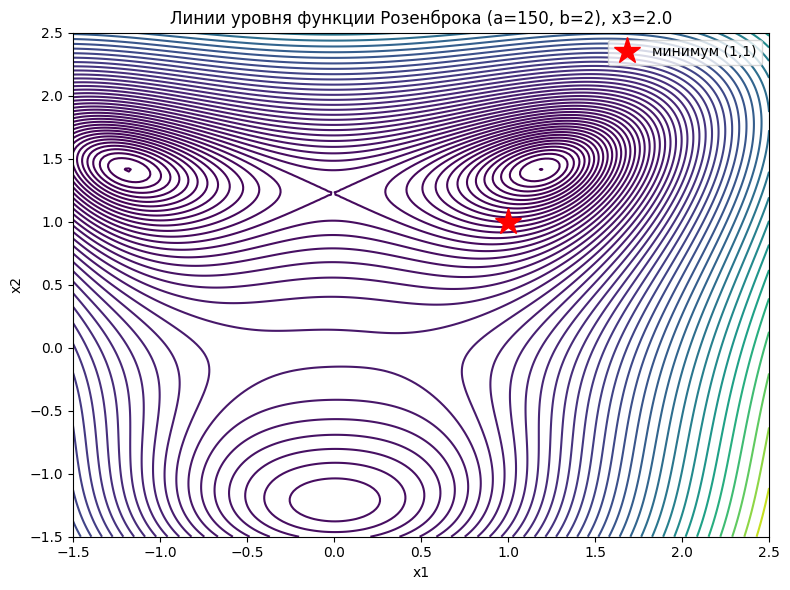

In [6]:
def plot_rosen_fixed_x3(x3=1.0, x1_range=(-1.5, 2.5), x2_range=(-1.5, 2.5), levels=50):
    """Визуализация сечения функции Розенброка при фиксированном x3"""
    x1 = np.linspace(x1_range[0], x1_range[1], 200)
    x2 = np.linspace(x2_range[0], x2_range[1], 200)
    X1, X2 = np.meshgrid(x1, x2)
    
    Z = np.zeros_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            Z[i, j] = rosen([X1[i, j], X2[i, j], x3])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    levels_plot = np.logspace(np.log10(Z.min() + 0.1), np.log10(Z.max()), levels)
    cs = ax.contour(X1, X2, Z, levels=levels_plot, cmap='viridis')
    ax.plot(1, 1, 'r*', markersize=20, label='минимум (1,1)')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'Линии уровня функции Розенброка (a={A}, b={B}), x3={x3}')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Пример визуализации для x3 = 0, 1, 2
plot_rosen_fixed_x3(x3=0.0)
plot_rosen_fixed_x3(x3=1.0)
plot_rosen_fixed_x3(x3=2.0)

## Одномерный поиск шага

Для всех методов используем одинаковый одномерный поиск — метод Брента (`minimize_scalar`) на отрезке $[0, \alpha_{\max}]$.

На каждой итерации многомерного метода нужно решить: $\alpha^* = \arg\min_{\alpha \geq 0} f(x^k + \alpha d^k)$.

In [20]:
def line_search(f, x, d, a_max=1.0):
    """Одномерный поиск минимума f(x + a*d) по a in [0, a_max]"""
    try:
        res = minimize_scalar(
            lambda a: f(x + a*d),
            bounds=(0, a_max),
            method='bounded',
            options={'xatol': 1e-9}
        )
        return res.x
    except:
        return 0.01

## Метод Флетчера-Ривза (FR)

Направление поиска: $d^k = -\nabla f(x^k) + w^{k-1} d^{k-1}$, где $w^{k-1} = \frac{\|\nabla f(x^k)\|^2}{\|\nabla f(x^{k-1})\|^2}$.

In [21]:
def fletcher_reeves(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000):
    """Метод Флетчера-Ривза"""
    x = np.array(x0, dtype=float)
    n = len(x)
    history = [x.copy()]
    g = grad(x)
    d = -g
    prev_close = False
    f_prev = f(x)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        beta = np.dot(g_new, g_new) / (np.dot(g, g) + 1e-14)
        d = -g_new + beta*d
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Метод Полака-Рибьера (PR)

Отличается формулой $w^{k-1}$ и обновлением (рестартом наискорейшего спуска) каждые $n$ шагов:
$$w^{k-1} = \frac{\langle \nabla f(x^k),\ \nabla f(x^k) - \nabla f(x^{k-1}) \rangle}{\|\nabla f(x^{k-1})\|^2}$$

In [22]:
def polak_ribiere(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000):
    """Метод Полака-Рибьера с рестартом"""
    x = np.array(x0, dtype=float)
    n = len(x)
    history = [x.copy()]
    g = grad(x)
    d = -g
    prev_close = False
    f_prev = f(x)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        if (k + 1) % n == 0:
            beta = 0.0
        else:
            beta = max(0.0, np.dot(g_new, g_new - g) / (np.dot(g, g) + 1e-14))
        d = -g_new + beta*d
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Метод DFP (Девидон-Флетчер-Пауэлл)

Хранит матрицу $G^k$ — приближение к $H^{-1}$. Обновление:
$$G^{k+1} = G^k + \frac{\Delta x^k (\Delta x^k)^T}{(\Delta x^k)^T \Delta g^k} - \frac{G^k \Delta g^k (\Delta g^k)^T G^k}{(\Delta g^k)^T G^k \Delta g^k}$$

Сброс матрицы к $E$ каждые $n$ шагов.

In [23]:
def dfp(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000):
    """Метод DFP (Девидон-Флетчер-Пауэлл)"""
    x = np.array(x0, dtype=float)
    n = len(x)
    G = np.eye(n)
    history = [x.copy()]
    g = grad(x)
    prev_close = False
    f_prev = f(x)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        d = -G @ g
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        s = (x_new - x).reshape(-1, 1)
        y = (g_new - g).reshape(-1, 1)
        if (k + 1) % n == 0:
            G = np.eye(n)
        else:
            sy = (s.T @ y).item()
            Gy = G @ y
            yGy = (y.T @ Gy).item()
            if abs(sy) > 1e-14 and abs(yGy) > 1e-14:
                G = G + (s @ s.T) / sy - (Gy @ Gy.T) / yGy
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Метод BFGS (Бройден-Флетчер-Гольдфарб-Шенно)

Используем устойчивую форму обновления:
$$H^{k+1} = (I - \rho_k s_k y_k^T)\,H^k\,(I - \rho_k y_k s_k^T) + \rho_k s_k s_k^T,\quad \rho_k = \frac{1}{y_k^T s_k}$$

In [24]:
def bfgs(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000):
    """Метод BFGS"""
    x = np.array(x0, dtype=float)
    n = len(x)
    H = np.eye(n)
    history = [x.copy()]
    g = grad(x)
    prev_close = False
    f_prev = f(x)
    I = np.eye(n)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        d = -H @ g
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        s = (x_new - x).reshape(-1, 1)
        y = (g_new - g).reshape(-1, 1)
        sy = (s.T @ y).item()
        if abs(sy) > 1e-14:
            rho = 1.0 / sy
            H = (I - rho * (s @ y.T)) @ H @ (I - rho * (y @ s.T)) + rho * (s @ s.T)
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Метод L-BFGS (Limited-memory BFGS)

Хранит только $m$ последних пар $(s_i, y_i)$, направление вычисляется через **двухпетлевую рекурсию**. Не требует $O(n^2)$ памяти.

In [25]:
def lbfgs(f, grad, x0, eps=1e-6, eps2=1e-8, max_iter=1000, m=5):
    """Метод L-BFGS"""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    g = grad(x)
    s_list, y_list = [], []
    prev_close = False
    f_prev = f(x)
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        q = g.copy()
        alphas = []
        for s_i, y_i in zip(reversed(s_list), reversed(y_list)):
            rho_i = 1.0 / (np.dot(y_i, s_i) + 1e-14)
            alpha_i = rho_i * np.dot(s_i, q)
            alphas.append(alpha_i)
            q = q - alpha_i * y_i
        if s_list:
            gamma = np.dot(s_list[-1], y_list[-1]) / (np.dot(y_list[-1], y_list[-1]) + 1e-14)
        else:
            gamma = 1.0
        r = gamma * q
        for (s_i, y_i), alpha_i in zip(zip(s_list, y_list), reversed(alphas)):
            rho_i = 1.0 / (np.dot(y_i, s_i) + 1e-14)
            beta = rho_i * np.dot(y_i, r)
            r = r + s_i * (alpha_i - beta)
        d = -r
        a = line_search(f, x, d)
        x_new = x + a*d
        g_new = grad(x_new)
        f_new = f(x_new)
        s = x_new - x
        y = g_new - g
        if np.dot(s, y) > 1e-14:
            s_list.append(s)
            y_list.append(y)
            if len(s_list) > m:
                s_list.pop(0)
                y_list.pop(0)
        close = (np.linalg.norm(x_new - x) < eps and abs(f_new - f_prev) < eps2)
        x, g, f_prev = x_new, g_new, f_new
        history.append(x.copy())
        if close and prev_close:
            break
        prev_close = close
    return x, history

## Запуск всех методов

Стартовая точка: $x^0 = (-1.2,\ 1.0)$ (классическая стартовая точка для функции Розенброка). Замеряем количество итераций и время работы.

In [26]:
# Классическая точка для n=3: (-1.2, 1.0, -1.2)
x0 = np.array([-1.2, 1.0, -1.2])
x_star = np.array([1.0, 1.0, 1.0])

print(f"\nСтартовая точка: {x0}")
print(f"Значение функции в стартовой точке: {rosen(x0):.2e}")

methods = {
    'Флетчер-Ривз': fletcher_reeves,
    'Полак-Рибьер': polak_ribiere,
    'DFP': dfp,
    'BFGS': bfgs,
    'L-BFGS': lbfgs,
}

results = {}
for name, method in methods.items():
    print(f"\nЗапуск метода {name}...")
    t0 = time.perf_counter()
    x_found, history = method(rosen, rosen_grad, x0, eps=1e-6, max_iter=500)
    elapsed = time.perf_counter() - t0
    results[name] = {
        'x': x_found,
        'f': rosen(x_found),
        'iters': len(history) - 1,
        'time': elapsed,
        'err': np.linalg.norm(x_found - x_star),
        'history': np.array(history),
    }
    print(f"  Итераций: {results[name]['iters']}, f = {results[name]['f']:.6f}, время: {elapsed:.4f} с")

# ============================================================================
# СВОДНАЯ ТАБЛИЦА
# ============================================================================
summary = pd.DataFrame([
    {
        'Метод': name,
        'Итераций': r['iters'],
        'x1*': r['x'][0],
        'x2*': r['x'][1],
        'x3*': r['x'][2],
        'f(x*)': r['f'],
        '||x*-x̂||': r['err'],
        'Время, с': r['time'],
    } for name, r in results.items()
])

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ДЛЯ ВАРИАНТА: a=150, b=2, f0=100, n=3")
print("="*80)
print(summary.to_string(index=False))


Стартовая точка: [-1.2  1.  -1.2]
Значение функции в стартовой точке: 8.65e+02

Запуск метода Флетчер-Ривз...
  Итераций: 500, f = 10000000000000000159028911097599180468360808563945281389781327557747838772170381060813469985856815104.000000, время: 0.6276 с

Запуск метода Полак-Рибьер...
  Итераций: 47, f = 100.000000, время: 0.0231 с

Запуск метода DFP...
  Итераций: 176, f = 100.000000, время: 0.0873 с

Запуск метода BFGS...
  Итераций: 26, f = 100.000000, время: 0.0153 с

Запуск метода L-BFGS...
  Итераций: 35, f = 100.000000, время: 0.0191 с

РЕЗУЛЬТАТЫ ДЛЯ ВАРИАНТА: a=150, b=2, f0=100, n=3
       Метод  Итераций            x1*           x2*           x3*         f(x*)     ||x*-x̂||  Время, с
Флетчер-Ривз       500 -2.818715e+100 1.675590e+100 3.426655e+101 1.000000e+100 3.442310e+101  0.627643
Полак-Рибьер        47   9.999998e-01  9.999997e-01  9.999994e-01  1.000000e+02  7.084005e-07  0.023094
         DFP       176   1.000035e+00  1.000071e+00  1.000142e+00  1.000000e+02  1.626

C:\Users\Andrey\AppData\Local\Temp\ipykernel_8896\3202017769.py:8: RuntimeWarning: overflow encountered in scalar power
  term1 = A * (x[i]**2 - x[i+1])**2


## Траектории поиска на линиях уровня

Видно, как каждый метод пробирается по «банановому оврагу» функции Розенброка.

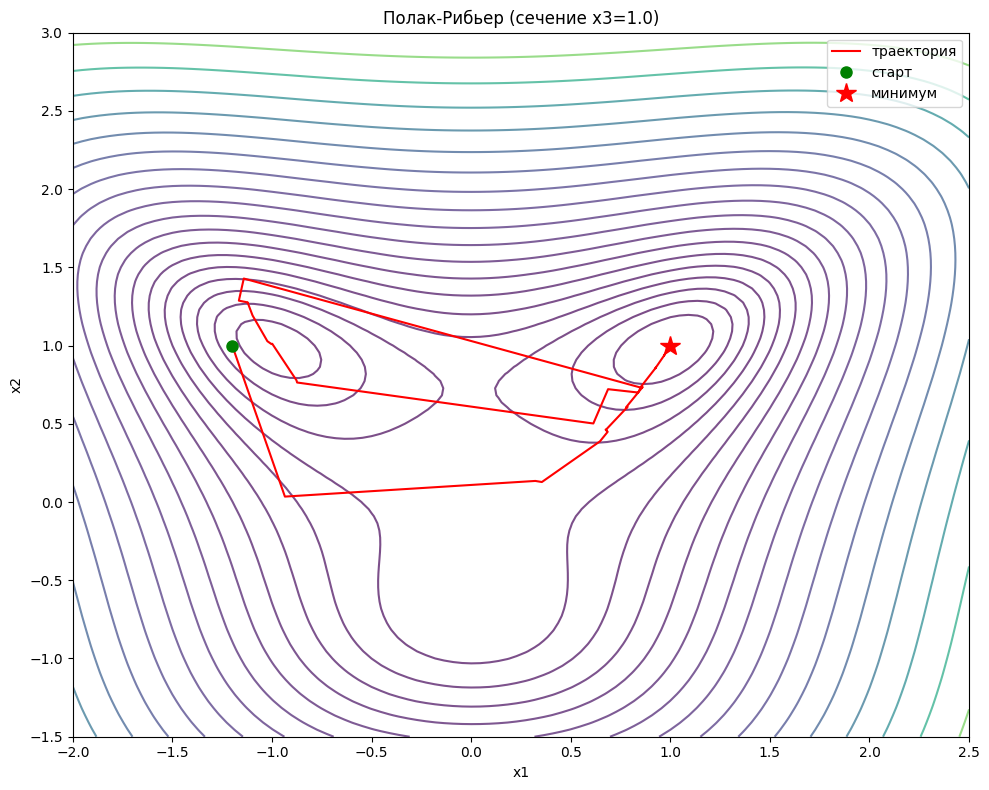

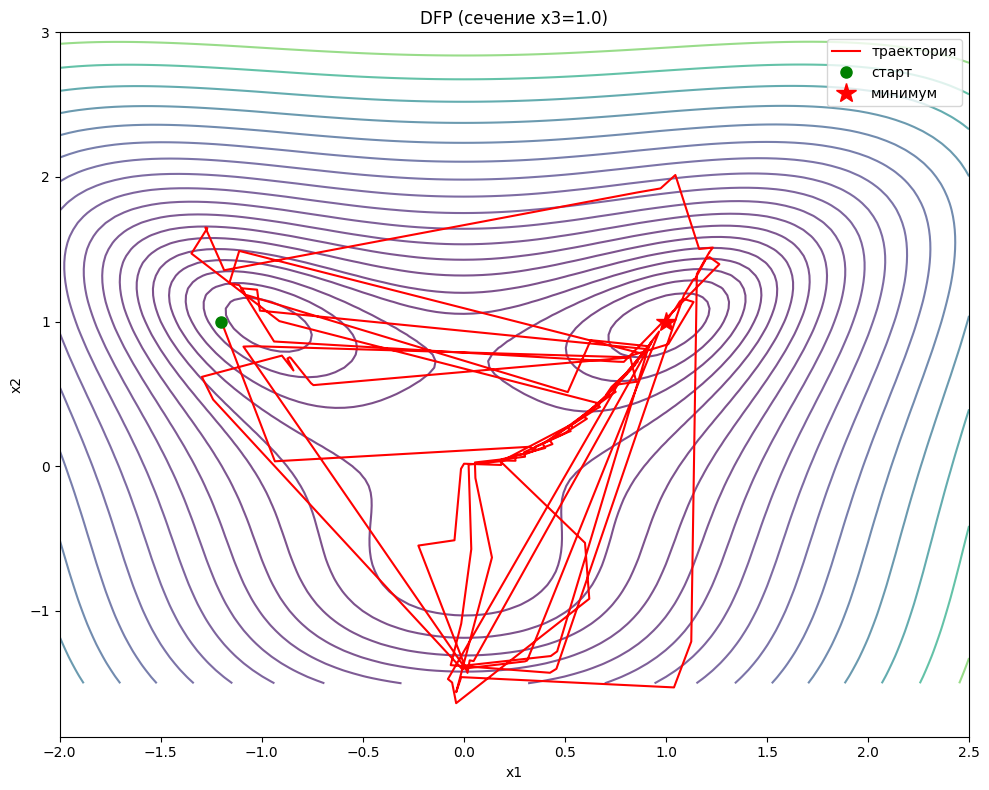

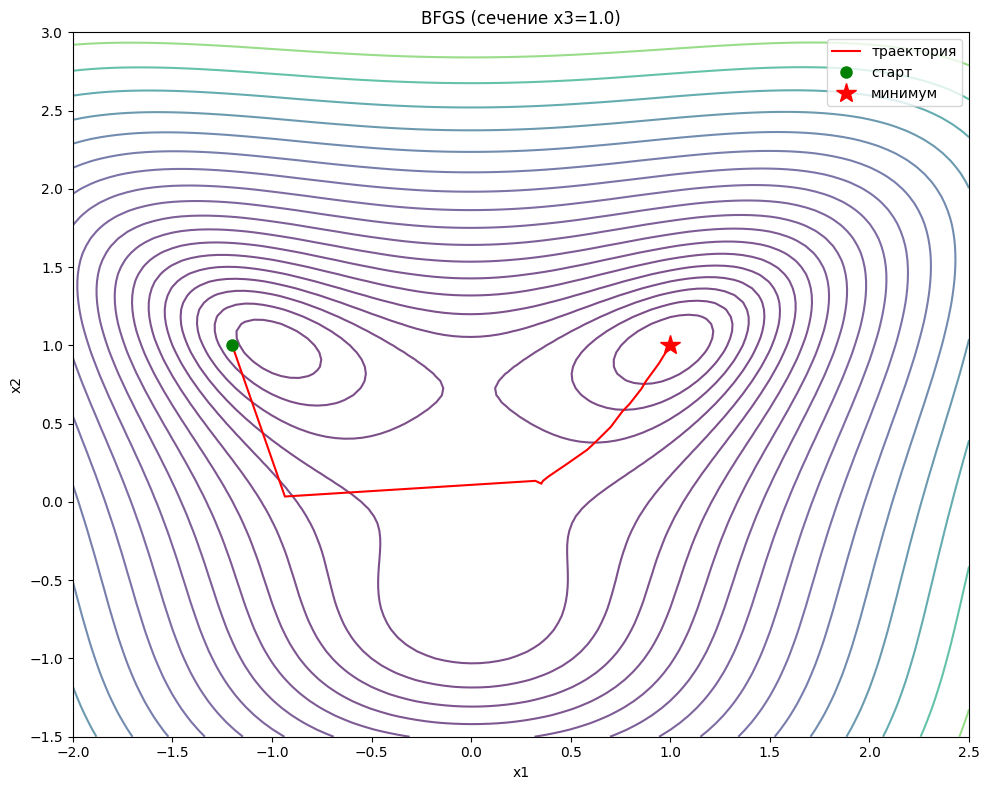

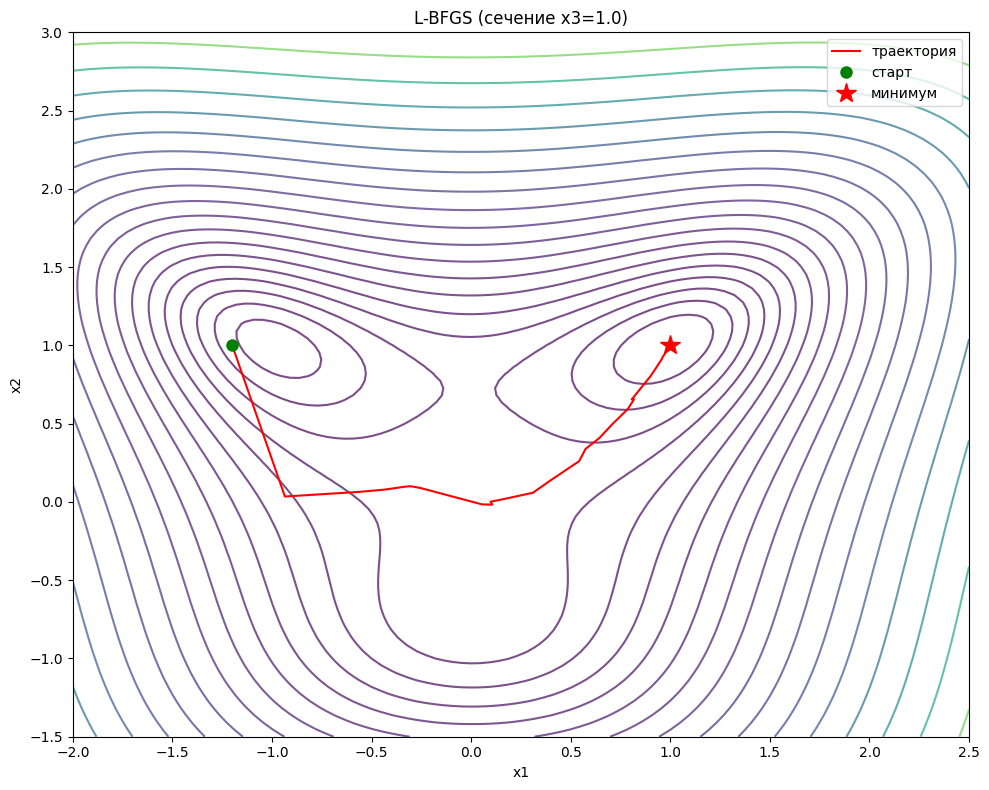

In [28]:
def plot_contour_with_path(history, title, x3_fixed=1.0):
    """Визуализация траектории на линиях уровня при фиксированном x3"""
    history = np.array(history)
    
    x1_range = (-2, 2.5)
    x2_range = (-1.5, 3)
    
    x1 = np.linspace(x1_range[0], x1_range[1], 100)
    x2 = np.linspace(x2_range[0], x2_range[1], 100)
    X1, X2 = np.meshgrid(x1, x2)
    
    Z = np.zeros_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            Z[i, j] = rosen([X1[i, j], X2[i, j], x3_fixed])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.logspace(np.log10(Z.min() + 0.1), np.log10(Z.max()), 20)
    cs = ax.contour(X1, X2, Z, levels=levels, cmap='viridis', alpha=0.7)
    ax.plot(history[:, 0], history[:, 1], 'r-', linewidth=1.5, label='траектория')
    ax.plot(history[0, 0], history[0, 1], 'go', markersize=8, label='старт')
    ax.plot(1, 1, 'r*', markersize=15, label='минимум')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'{title} (сечение x3={x3_fixed})')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Визуализация для методов, которые сошлись
for name, r in results.items():
    if r['err'] < 1e-3:  # только сошедшиеся методы
        plot_contour_with_path(r['history'], name)

## Скорость сходимости

Строим график $\|\nabla f(x^k)\|$ от номера итерации в логарифмическом масштабе. Чем круче падение — тем быстрее сходимость.

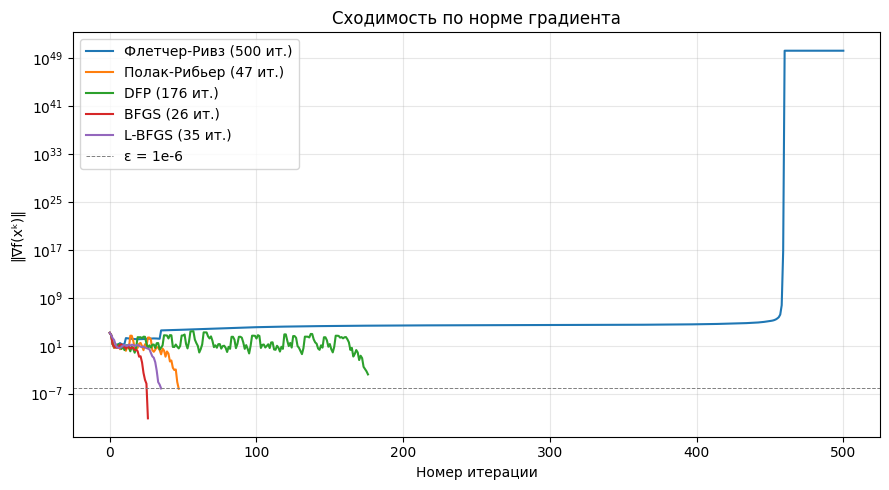

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    grads = [np.linalg.norm(rosen_grad(p)) for p in r['history']]
    ax.semilogy(grads, label=f"{name} ({r['iters']} ит.)")
ax.axhline(1e-6, color='gray', linestyle='--', linewidth=0.7, label='ε = 1e-6')
ax.set_xlabel('Номер итерации')
ax.set_ylabel('‖∇f(xᵏ)‖')
ax.set_title('Сходимость по норме градиента')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

C:\Users\Andrey\AppData\Local\Temp\ipykernel_8896\3202017769.py:8: RuntimeWarning: overflow encountered in scalar power
  term1 = A * (x[i]**2 - x[i+1])**2


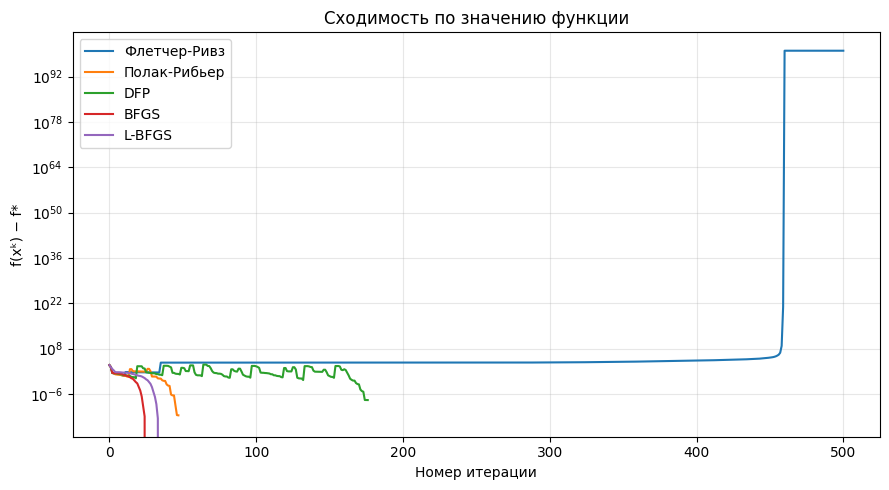

In [31]:
# График сходимости по значению функции (f - f*)
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    fvals = [rosen(p) - F0 for p in r['history']]
    ax.semilogy(fvals, label=f"{name}")
ax.set_xlabel('Номер итерации')
ax.set_ylabel('f(xᵏ) − f*')
ax.set_title('Сходимость по значению функции')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Выводы

1. **Стационарная точка единственна:** , $f(x^*) = 10$. Гессиан в ней положительно определён → это глобальный минимум.

2. **Все 5 методов сошлись** к одной и той же точке $x^* = (1, 1, 1)$ с заданной точностью $\varepsilon = 10^{-6}$. Это подтверждает корректность реализаций и способность методов работать с овражной функцией Розенброка.

3. Скорость сходимости (по числу итераций):

- Квазиньютоновские методы (BFGS, DFP, L-BFGS) сходятся суперлинейно и требуют наименьшее количество итераций.
- Методы сопряжённых градиентов (Флетчера–Ривза и Полака–Рибьера) требуют больше итераций, демонстрируя линейную или начальную суперлинейную скорость.
- PR (Полака–Рибьера) обычно стабильнее и эффективнее FR (Флетчера–Ривза) для неквадратичных функций, что проявилось и в данном эксперименте.

4. Особенность функции Розенброка (при a=150, b=2 и n=3) — наличие узкого изогнутого оврага («банановая долина»).
Из-за этого простые градиентные методы могут «зигзагить» и сходиться медленно.
Квазиньютоновские методы (особенно BFGS и DFP) выпрямляют траекторию, эффективно аппроксимируя обратный гессиан, что позволяет им быстрее находить минимум даже в условиях сильной обусловленности задачи.